

---


- [CHIRPS](https://developers.google.com/earth-engine/datasets/catalog/UCSB-CHG_CHIRPS_DAILY?hl=pt-br): `DESDE 1981` - `DIÁRIO` - `5566m` - `2 MESES DE ATRASO`

- [IMERGE](https://developers.google.com/earth-engine/datasets/catalog/NASA_GPM_L3_IMERG_V07?hl=pt-br): `DESDE 2000` - `A CADA 30 MIN` - `11132m` - `2 DIAS DE ATRASO` - **MELHOR OPÇÃO**

- [GSMAP](https://developers.google.com/earth-engine/datasets/catalog/JAXA_GPM_L3_GSMaP_v8_operational?hl=pt-br): `DESDE 1998` - `A CADA 1 HORA` - `11132m` - `2 DIAS DE ATRASO`




---




# Instalando Xee e inicializando GEE

Se você tiver uma conta do Earth Engine você poderá encontrar a sua ID de um projeto do GEE acessando https://code.earthengine.google.com/ com sua conta google, e depois verificando do lado superior direito do Code Editor o nome da sua ID.

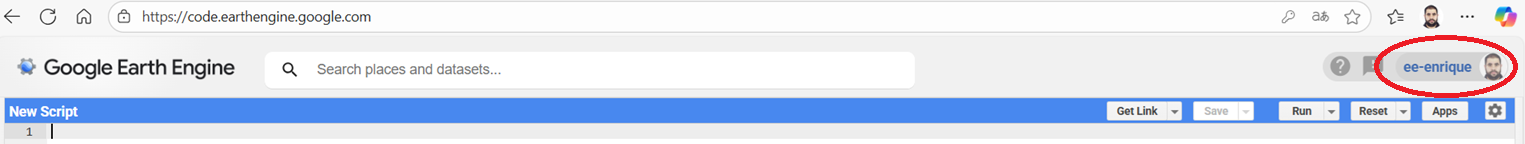

Insira a sua ID no campo `geemap.ee_initialize(project='SUA ID')`.

In [1]:
# instalando Xee

# importa bibliotecas
import ee
import geemap
import xee
import xarray as xr
import time
import pandas as pd


# inicializando pelo GEE
geemap.ee_initialize(project='d2021028876')

In [2]:
dir = r'C:\Users\xloko\OneDrive\Área de Trabalho\GIT\TCC_GEE\Analises\output'  # diretorio onde serao salvos os arquivos


# Processamento

In [3]:
%%time
# define a região de interesse: queremos a área do Brasil
brasil = ee.FeatureCollection('FAO/GAUL/2015/level0').filter(ee.Filter.eq('ADM0_NAME', 'Brazil'))
#mg = ee.FeatureCollection('FAO/GAUL/2015/level1').filter(ee.Filter.eq('ADM1_NAME', 'Minas Gerais'))

# define o ano de processamento
ano = '2022'

# função de agrupamento DIÁRIO
def diario(data, col):
    data_i = ee.Date(data)
    data_f = data_i.advance(1, 'day')
    soma_diaria = col.filterDate(data_i, data_f).sum()
    return soma_diaria.set('system:time_start', data_i.millis())

# loop dos meses
for file in pd.date_range(f'{ano}0101', f'{ano}1231', freq='ME'):

    # extrai ano e mês
    ano = file.strftime('%Y')
    mes = file.strftime('%m')

    # monta data no formato "2024-01-01"
    date = f"{ano}-{mes}-01"

    print('#-------------------------------------------#')
    print(f' PROCESSANDO =====>>>>: {date}')
    print('#-------------------------------------------#')

    # mês atual
    mes_atual = ee.Date(date)

    # próximo mês
    mes_prox = mes_atual.advance(1, 'month')

    # dia inicial e final do mês no formato string
    data_string_i = mes_atual.format('YYYY-MM-dd')
    data_string_f = mes_prox.format('YYYY-MM-dd')

    print('Data Inicial:', data_string_i.getInfo())
    print('Data Final', data_string_f.getInfo())
    print('#-------------------------------------------#')
    print('\n')

    # CHIRPS - "precipitation" (1 dia) - mm/d
    chirps = ee.ImageCollection('UCSB-CHG/CHIRPS/DAILY') \
               .filterDate(mes_atual, mes_prox) \
               .select(['precipitation'], ['precip_chirps']) \
               .map(lambda img: img.clip(brasil).copyProperties(img, img.propertyNames()))

    # IMERGE - "precipitation" (30 min) - mm/h
    imerge = ee.ImageCollection("NASA/GPM_L3/IMERG_V07") \
               .filterDate(mes_atual, mes_prox) \
               .select(['precipitation'], ['precip_imerge']) \
               .map(lambda img: img.multiply(0.5).copyProperties(img, ['system:time_start'])) \
               .map(lambda img: img.clip(brasil).copyProperties(img, img.propertyNames()))

    # GSMAP - "hourlyPrecipRate" (1 hora) - mm/h
    gsmap = ee.ImageCollection('JAXA/GPM_L3/GSMaP/v8/operational') \
              .filterDate(mes_atual, mes_prox) \
              .select(['hourlyPrecipRate'], ['precip_gsmap']) \
              .map(lambda img: img.clip(brasil).copyProperties(img, img.propertyNames()))

    # diferença de datas em DIAS
    data_dif = mes_prox.difference(mes_atual, 'day').round()

    # lista dos dias
    lista_datas = ee.List.sequence(0, ee.Number(data_dif).subtract(1)).map(lambda x: mes_atual.advance(x, 'day'))

    # agrupamento DIÁRIO para todas as coleções
    chirps_diario = ee.ImageCollection(lista_datas.map(lambda x: diario(x, chirps)))
    imerge_diario = ee.ImageCollection(lista_datas.map(lambda x: diario(x, imerge)))
    gsmap_diario = ee.ImageCollection(lista_datas.map(lambda x: diario(x, gsmap)))

    # combina os campos do chirps, imerge e gsmap
    precip_combinada = chirps_diario.combine(imerge_diario).combine(gsmap_diario)

    # gera dataset
    ds = xr.open_dataset(precip_combinada,
                         engine = 'ee',
                         crs = 'EPSG:4326',
                         scale = 0.15,
                         geometry = brasil.geometry())

    ds.to_netcdf(f'{dir}/precipitacao_diaria_brasil_chirps_imerge_gsmap_15km_{ano}-{mes}.nc')

#-------------------------------------------#
 PROCESSANDO =====>>>>: 2022-01-01
#-------------------------------------------#
Data Inicial: 2022-01-01
Data Final 2022-02-01
#-------------------------------------------#


#-------------------------------------------#
 PROCESSANDO =====>>>>: 2022-02-01
#-------------------------------------------#
Data Inicial: 2022-02-01
Data Final 2022-03-01
#-------------------------------------------#


#-------------------------------------------#
 PROCESSANDO =====>>>>: 2022-03-01
#-------------------------------------------#
Data Inicial: 2022-03-01
Data Final 2022-04-01
#-------------------------------------------#


#-------------------------------------------#
 PROCESSANDO =====>>>>: 2022-04-01
#-------------------------------------------#
Data Inicial: 2022-04-01
Data Final 2022-05-01
#-------------------------------------------#


#-------------------------------------------#
 PROCESSANDO =====>>>>: 2022-05-01
#------------------------------

In [4]:
chuva = xr.open_dataset(r"C:\Users\xloko\OneDrive\Área de Trabalho\GIT\TCC_GEE\Analises\output\precipitacao_diaria_brasil_chirps_imerge_gsmap_15km_2024-01.nc")

chuva

<xarray.Dataset> Size: 29MB
Dimensions:        (time: 31, lon: 301, lat: 260)
Coordinates:
  * time           (time) datetime64[ns] 248B 2024-01-01 ... 2024-01-10
  * lon            (lon) float64 2kB -73.91 -73.76 -73.61 ... -29.06 -28.91
  * lat            (lat) float64 2kB -33.68 -33.53 -33.38 ... 4.875 5.025 5.175
Data variables:
    precip_chirps  (time, lon, lat) float32 10MB ...
    precip_imerge  (time, lon, lat) float32 10MB ...
    precip_gsmap   (time, lon, lat) float32 10MB ...
Attributes:
    crs:      EPSG:4326

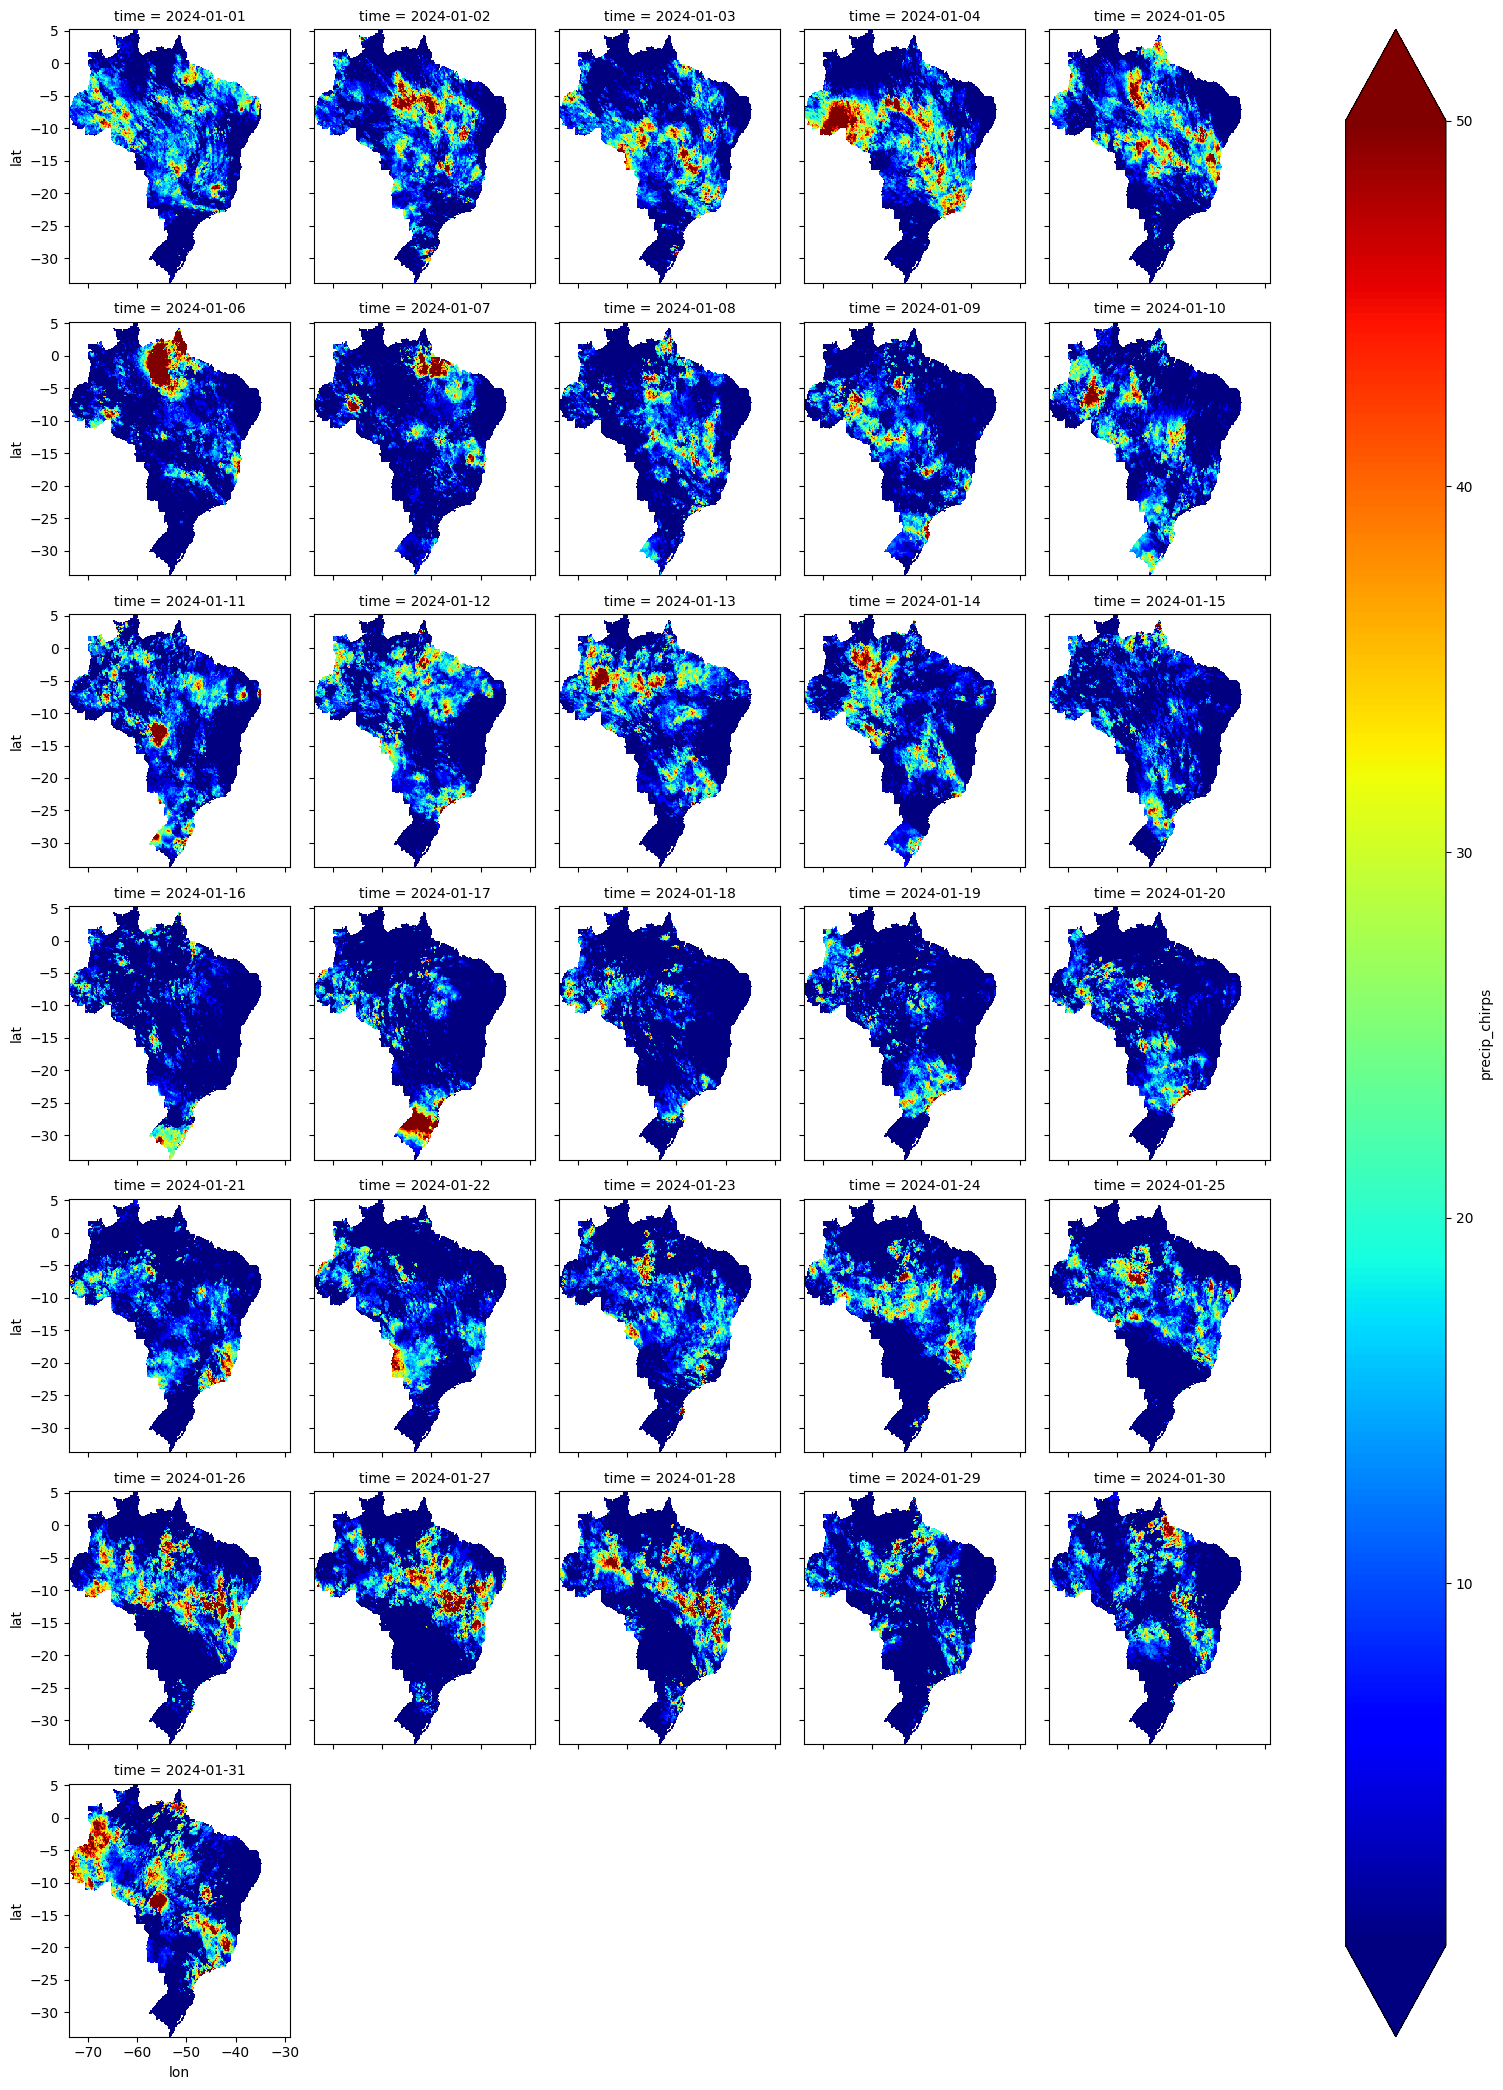

In [5]:
# gráfico: GPM
ds = xr.open_dataset(r"C:\Users\xloko\OneDrive\Área de Trabalho\GIT\TCC_GEE\Analises\output\precipitacao_diaria_brasil_chirps_imerge_gsmap_15km_2024-01.nc")
ds = ds.sortby('time')
ds.precip_chirps.plot(x = 'lon',
                      y = 'lat',
                      col = 'time',
                      col_wrap = 5,
                      robust = True,
                      cmap = 'jet',
                      vmin = 0.1,
                      vmax = 50)

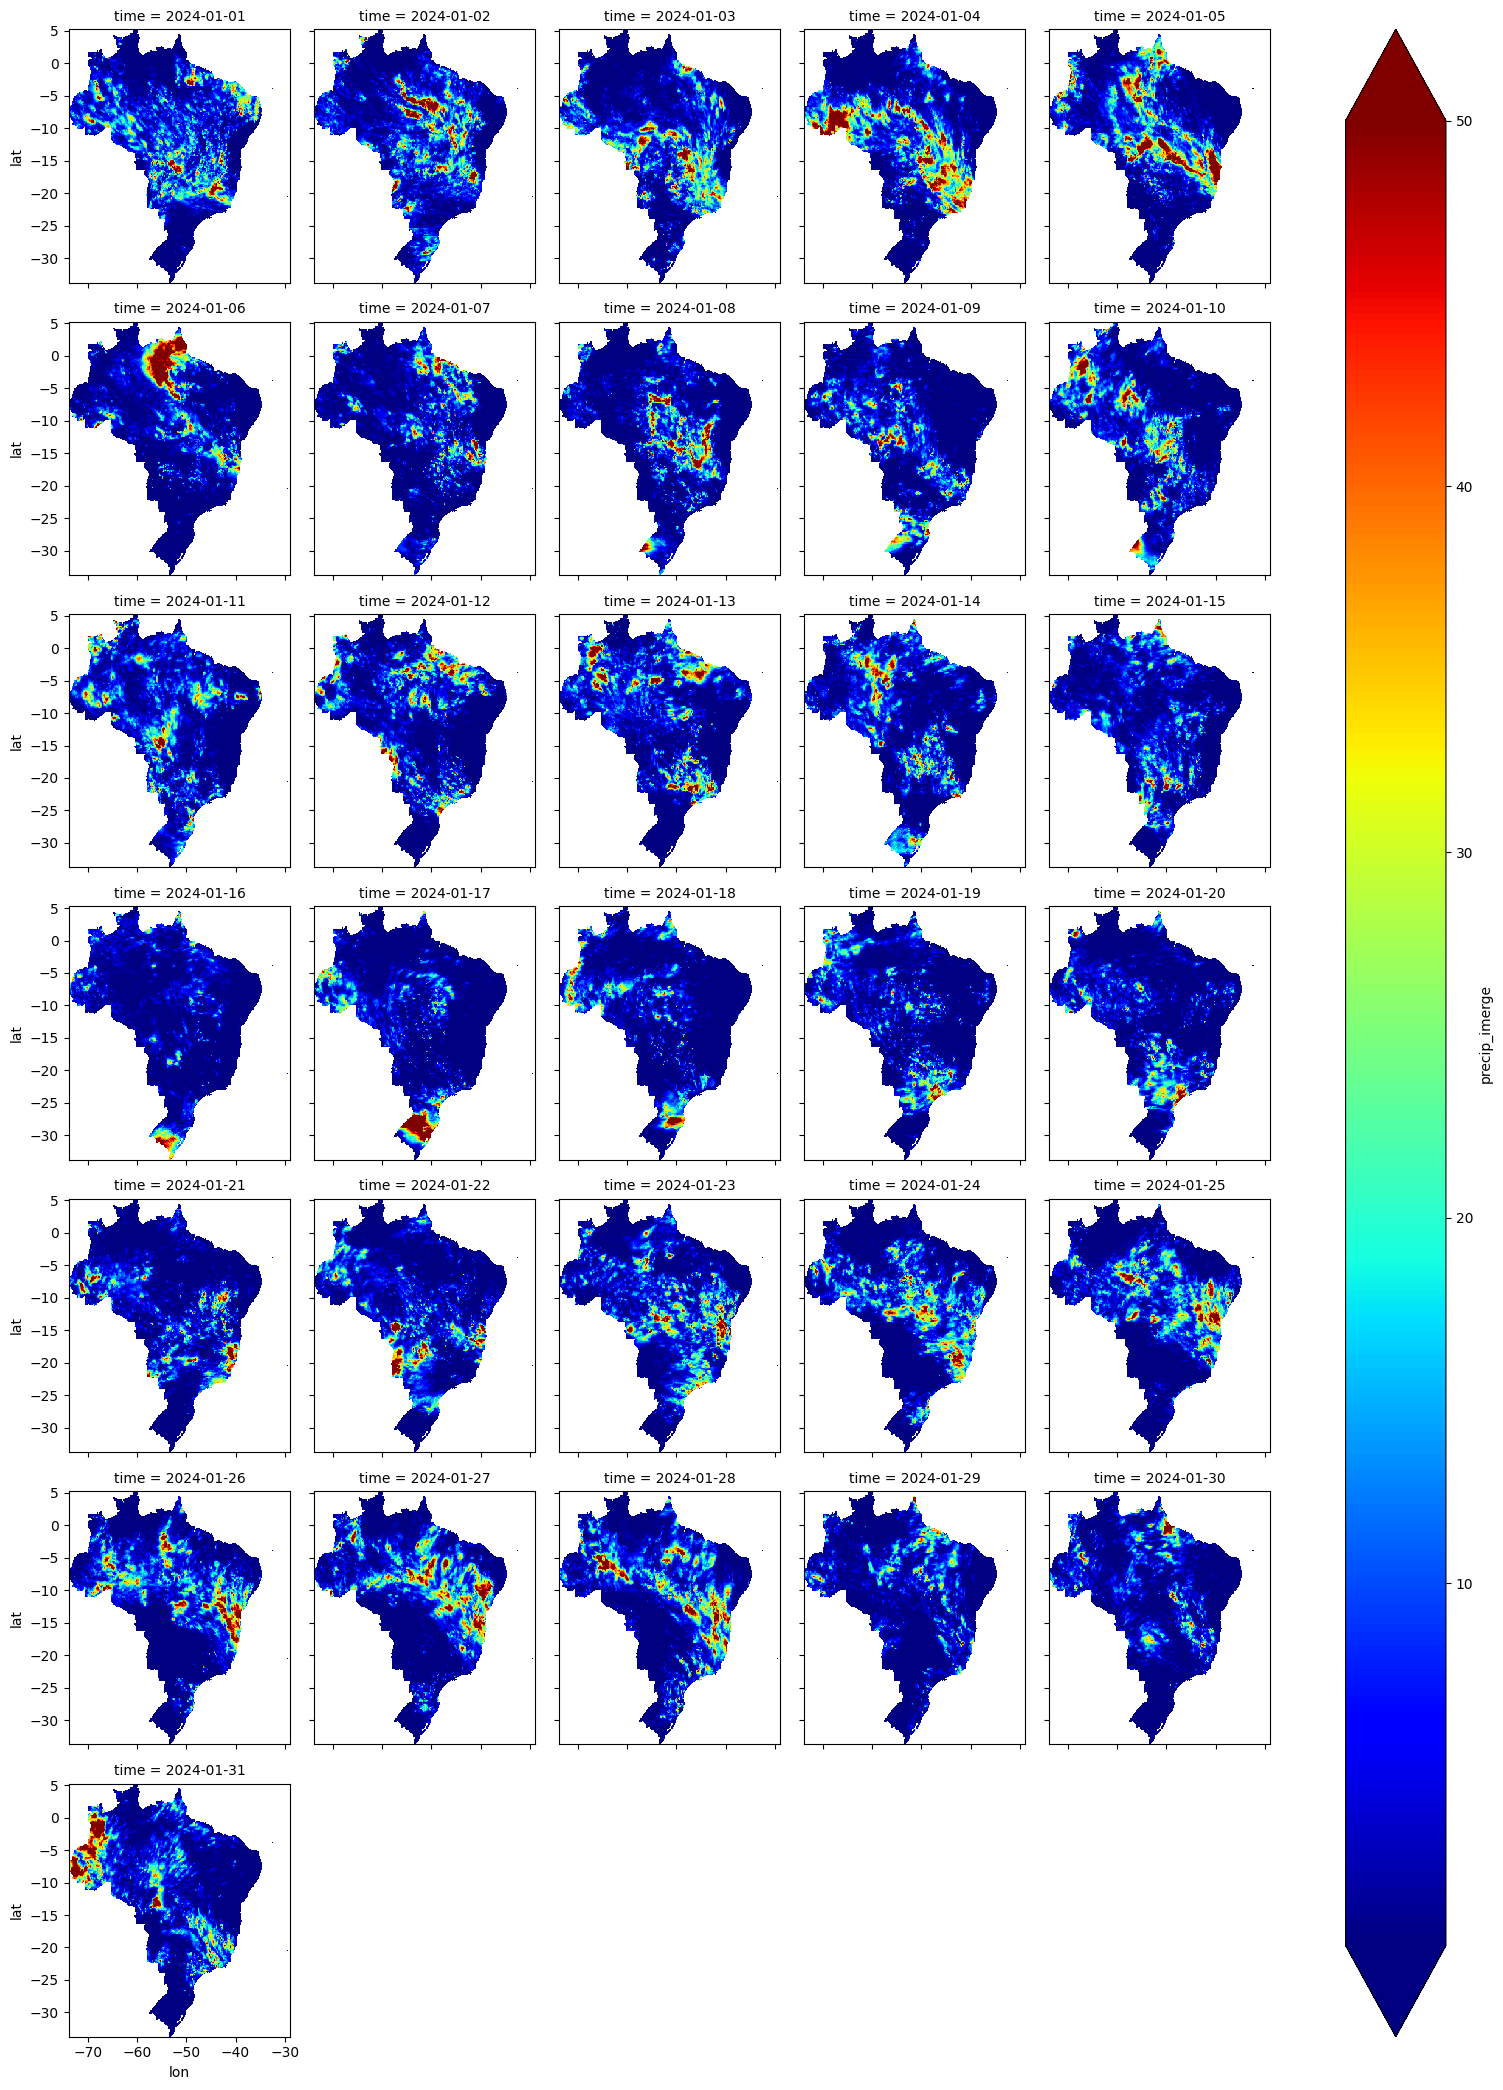

In [6]:
# gráfico: IMERGE
ds.precip_imerge.plot(x = 'lon',
                      y = 'lat',
                      col = 'time',
                      col_wrap = 5,
                      robust = True,
                      cmap = 'jet',
                      vmin = 0.1,
                      vmax = 50)

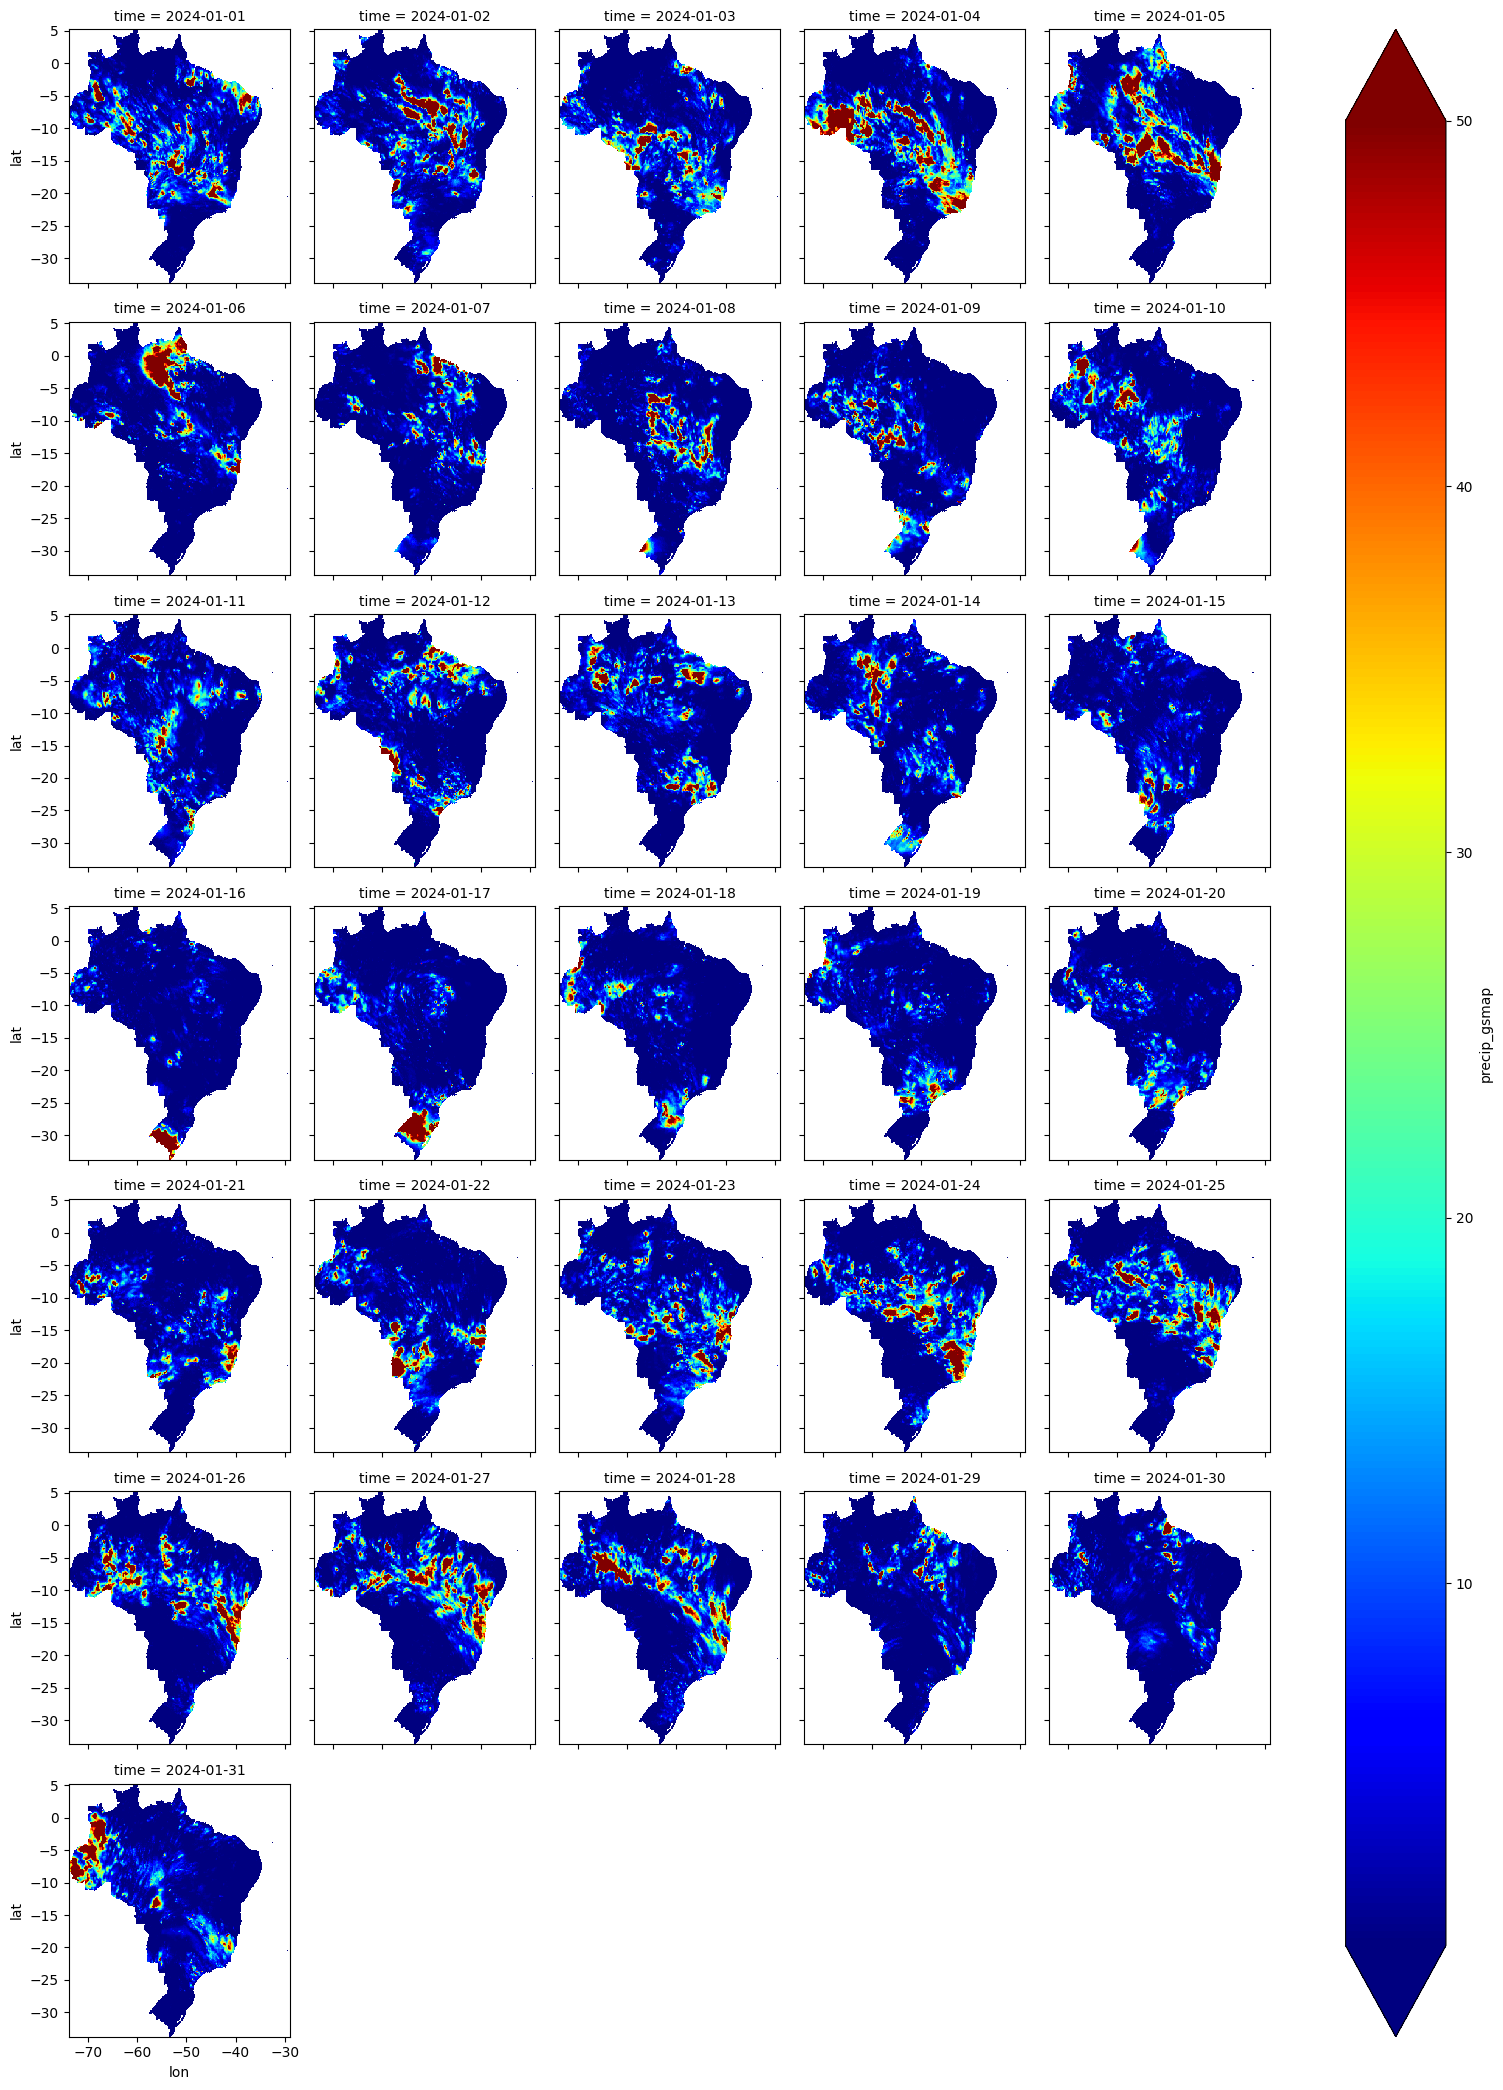

In [7]:
# gráfico: GSMAP
ds.precip_gsmap.plot(x = 'lon',
                      y = 'lat',
                      col = 'time',
                      col_wrap = 5,
                      robust = True,
                      cmap = 'jet',
                      vmin = 0.1,
                      vmax = 50)

In [8]:
ds = xr.open_dataset(r"C:\Users\xloko\OneDrive\Área de Trabalho\GIT\TCC_GEE\Analises\output\precipitacao_diaria_brasil_chirps_imerge_gsmap_15km_2024-01.nc")
ds.precip_chirps

<xarray.DataArray 'precip_chirps' (time: 31, lon: 301, lat: 260)> Size: 10MB
[2426060 values with dtype=float32]
Coordinates:
  * time     (time) datetime64[ns] 248B 2024-01-01 2024-01-02 ... 2024-01-10
  * lon      (lon) float64 2kB -73.91 -73.76 -73.61 ... -29.21 -29.06 -28.91
  * lat      (lat) float64 2kB -33.68 -33.53 -33.38 -33.23 ... 4.875 5.025 5.175
Attributes:
    id:             precip_chirps
    data_type:      {'type': 'PixelType', 'precision': 'double'}
    crs:            EPSG:4326
    crs_transform:  [1 0 0 0 1 0]
    bounds:         [-73.98552953 -33.75040078 -28.847695     5.26487847]

In [9]:
import os
import xarray as xr

# diretório com os arquivos mensais
dir_out = r'C:\Users\xloko\OneDrive\Área de Trabalho\GIT\TCC_GEE\Analises\output'

ano = 2024


arquivos = [
    os.path.join(dir_out, f'precipitacao_diaria_brasil_chirps_imerge_gsmap_15km_{ano}-{mes:02d}.nc')
    for mes in range(1, 13)
]
arquivos_existentes = [arq for arq in arquivos if os.path.exists(arq)]
print(arquivos_existentes)

if not arquivos_existentes:
    print(f"Nenhum arquivo encontrado para {ano}. Pulando...")
    

ds_anual = xr.open_mfdataset(arquivos_existentes, combine='nested', concat_dim='time')

saida = os.path.join(dir_out, f'precipitacao_brasil_chirps_imerge_gsmap_15km_{ano}.nc')
ds_anual.to_netcdf(saida)
ds_anual.close()

print(f"Arquivo anual salvo: {saida}")



['C:\\Users\\xloko\\OneDrive\\Área de Trabalho\\GIT\\TCC_GEE\\Analises\\output\\precipitacao_diaria_brasil_chirps_imerge_gsmap_15km_2024-01.nc', 'C:\\Users\\xloko\\OneDrive\\Área de Trabalho\\GIT\\TCC_GEE\\Analises\\output\\precipitacao_diaria_brasil_chirps_imerge_gsmap_15km_2024-02.nc', 'C:\\Users\\xloko\\OneDrive\\Área de Trabalho\\GIT\\TCC_GEE\\Analises\\output\\precipitacao_diaria_brasil_chirps_imerge_gsmap_15km_2024-03.nc', 'C:\\Users\\xloko\\OneDrive\\Área de Trabalho\\GIT\\TCC_GEE\\Analises\\output\\precipitacao_diaria_brasil_chirps_imerge_gsmap_15km_2024-04.nc', 'C:\\Users\\xloko\\OneDrive\\Área de Trabalho\\GIT\\TCC_GEE\\Analises\\output\\precipitacao_diaria_brasil_chirps_imerge_gsmap_15km_2024-05.nc', 'C:\\Users\\xloko\\OneDrive\\Área de Trabalho\\GIT\\TCC_GEE\\Analises\\output\\precipitacao_diaria_brasil_chirps_imerge_gsmap_15km_2024-06.nc', 'C:\\Users\\xloko\\OneDrive\\Área de Trabalho\\GIT\\TCC_GEE\\Analises\\output\\precipitacao_diaria_brasil_chirps_imerge_gsmap_15km_2024

ValueError: The truth value of an array with more than one element is ambiguous. Use a.any() or a.all()

In [ ]:
import xarray as xr
import glob
import os

def juntar_netcdfs_mensais_para_anual(pasta_dos_arquivos, padrao_arquivos, arquivo_de_saida):
    
    caminho_busca = os.path.join(pasta_dos_arquivos, padrao_arquivos)
    lista_arquivos_mensais = sorted(glob.glob(caminho_busca))
    
    print(f"Encontrados {len(lista_arquivos_mensais)} arquivos para juntar:")
    
    for arquivo in lista_arquivos_mensais:
        print(f"  - {os.path.basename(arquivo)}")

    print("\nJuntando os arquivos...")
    dataset_anual = xr.open_mfdataset(lista_arquivos_mensais, combine='by_coords')
    
    print(f"Salvando o arquivo anual em: '{arquivo_de_saida}'")
    dataset_anual.to_netcdf(arquivo_de_saida)
    dataset_anual.close()
    
    print("\nProcesso concluído com sucesso!")




pasta_de_entrada = r'C:\Users\xloko\OneDrive\Área de Trabalho\GIT\TCC_GEE\Analises\output' 
arquivo_final_anual = r'C:\Users\xloko\OneDrive\Área de Trabalho\GIT\TCC_GEE\Analises\output\dado_anual_consolidado_2024.nc'


if not os.path.exists(pasta_de_entrada):
    print(f"Criando pasta de exemplo '{pasta_de_entrada}'. Por favor, adicione seus arquivos .nc nela e execute o script novamente.")
    os.makedirs(pasta_de_entrada)
else:
    juntar_netcdfs_mensais_para_anual(
        pasta_dos_arquivos=pasta_de_entrada,
        padrao_arquivos='*.nc',
        arquivo_de_saida=arquivo_final_anual
    )